In [1]:
!pip install xgboost lightgbm catboost optuna imbalanced-learn -q

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')






   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 8.1 MB/s eta 0:00:00


# alrIEEEna'26 — ML Challenge
## Binary Fault Detection: Normal (0) vs Faulty (1)
### IEEE SB, Graphic Era Hill University

## Problem Statement
Classify device operational status using 47 sensor
readings (F01-F47) as either Normal (0) or Faulty (1).

In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style='darkgrid', palette='husl')
plt.rcParams['figure.dpi'] = 120

In [3]:
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA


In [4]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

In [5]:
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, VotingClassifier, StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [6]:
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_validate
)
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

In [7]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


In [8]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


SEED = 42
np.random.seed(SEED)

In [9]:
from google.colab import files
uploaded = files.upload()

Saving TEST.csv to TEST.csv
Saving TRAIN.csv to TRAIN.csv


In [10]:
train = pd.read_csv('TRAIN.csv')
test  = pd.read_csv('TEST.csv')


In [11]:
print(train)

            F01       F02       F03       F04       F05       F06       F07  \
0      0.185570  0.004568  0.005362  0.003335  0.005415  0.004895  0.012764   
1      0.369536  0.003983  0.003386  0.004902  0.007570  0.012136  0.118050   
2      0.602510  0.008442  0.012961  0.012870  0.046885  0.115401  0.065688   
3      0.347957  0.064721  0.013611  0.011541  0.006492  0.008690  0.013192   
4      0.233653  0.012217  0.010088  0.022095  0.026040  0.015062  0.016063   
...         ...       ...       ...       ...       ...       ...       ...   
43771  1.231065  0.008631  0.010488  0.030072  0.224300  0.384893  0.452580   
43772  1.576213  0.019906  0.015115  0.034719  0.347274  0.913438  0.240656   
43773  0.523951  0.006851  0.012379  0.008150  0.012631  0.012130  0.033749   
43774  0.313915  0.003392  0.004212  0.004475  0.004765  0.005470  0.017687   
43775  0.206646  0.014795  0.012043  0.020157  0.044076  0.029703  0.021559   

            F08       F09       F10  ...       F39 

In [12]:
print(test)

          ID       F01       F02       F03       F04       F05       F06  \
0          1  0.277497  0.011515  0.009359  0.011706  0.015613  0.063679   
1          2  0.158754  0.013861  0.020935  0.002451  0.005939  0.006830   
2          3  0.504418  0.009106  0.007395  0.009073  0.029486  0.086782   
3          4  0.556345  0.005370  0.005670  0.005167  0.013731  0.014570   
4          5  0.128356  0.010014  0.016144  0.003891  0.004472  0.005297   
...      ...       ...       ...       ...       ...       ...       ...   
10939  10940  0.700169  0.016269  0.012949  0.022944  0.117091  0.176038   
10940  10941  1.823409  0.011113  0.010198  0.033226  0.285363  0.564903   
10941  10942  0.249093  0.019398  0.015813  0.016698  0.014141  0.021264   
10942  10943  0.475925  0.004989  0.003792  0.002713  0.009573  0.013896   
10943  10944  0.150631  0.144396  0.031949  0.022509  0.010502  0.011498   

            F07       F08       F09  ...           F38       F39        F40  \
0      0



Before training, we performed thorough data quality checks:

**Finding 1 — Duplicate Rows:**
Found 738 exact duplicate rows in training data.
All duplicates belonged to Normal (0) class.
Removed them to prevent model from over-learning
repeated patterns → cleaned dataset: 43,038 rows.

**Finding 2 — Outliers:**
All 47 features contained outliers detected via IQR method.
Worst case: F40 had 13,438 outlier values.
Fix: Used RobustScaler (uses median & IQR instead of
mean & std — not affected by extreme values).

**Finding 3 — Negative Values:**
10 out of 47 features contained negative values.
~21,000 negative entries per feature.
Fix: Created row_neg_count engineered feature to
track negative readings per device row.

**Finding 4 — Class Imbalance:**
Normal (0): 25,727 samples (59.8%)
Faulty (1): 17,311 samples (40.2%)
Ratio: 1.49:1 — mild imbalance.
Fix: class_weight=balanced for all models,
scale_pos_weight=1.49 specifically for XGBoost.

In [13]:
FEATURE_COLS = [f'F{str(i).zfill(2)}' for i in range(1, 48)]
TARGET_COL   = 'Class'


In [14]:
X      = train[FEATURE_COLS]
y      = train[TARGET_COL]
X_test = test[FEATURE_COLS]
test_ids = test['ID']


In [15]:
X


,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F38,F39,F40,F41,F42,F43,F44,F45,F46,F47
0,0.185570,0.004568,0.005362,0.003335,0.005415,0.004895,0.012764,0.120138,0.140450,3.361753,...,2.826142,0.041526,-0.230857,0.003310,0.042250,0.005975,0.002104,0.013878,0.001518,0.011347
1,0.369536,0.003983,0.003386,0.004902,0.007570,0.012136,0.118050,0.323925,0.132093,2.766117,...,2.955462,-0.141285,-6.222857,0.834177,0.227968,0.018463,-0.020487,0.001246,0.007489,0.008724
2,0.602510,0.008442,0.012961,0.012870,0.046885,0.115401,0.065688,0.306677,0.498805,4.521201,...,3.423784,0.011334,10.335251,-0.276614,-0.198900,-0.012756,0.014286,-0.001866,0.002687,0.013452
3,0.347957,0.064721,0.013611,0.011541,0.006492,0.008690,0.013192,0.164553,0.298665,3.170847,...,2.473058,0.190479,2.864912,-1.921939,0.891690,1.108098,0.635431,0.081368,-0.000225,0.009166
4,0.233653,0.012217,0.010088,0.022095,0.026040,0.015062,0.016063,0.084648,0.213367,8.150943,...,7.595287,0.203164,0.001812,-0.092731,0.005280,-0.213985,0.032195,0.002081,0.028930,-0.025912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43771,1.231065,0.008631,0.010488,0.030072,0.224300,0.384893,0.452580,0.878004,0.583311,4.336341,...,3.272185,0.076438,-10.673305,0.874835,0.035450,0.001390,-0.003333,0.002385,0.001182,-0.010616
43772,1.576213,0.019906,0.015115,0.034719,0.347274,0.913438,0.240656,0.469324,1.118124,3.395661,...,2.916853,-0.033483,-19.302853,5.744947,0.373802,0.006406,-0.008244,-0.081317,-0.007015,-0.001864
43773,0.523951,0.006851,0.012379,0.008150,0.012631,0.012130,0.033749,0.150855,0.500064,3.677857,...,2.750475,0.051253,0.825418,0.006428,-0.012533,-0.034026,0.000177,0.005071,0.005763,0.005489
43774,0.313915,0.003392,0.004212,0.004475,0.004765,0.005470,0.017687,0.034267,0.311377,2.097170,...,1.667138,-0.012220,-0.630316,-0.006486,-0.042303,0.037734,0.039146,-0.008112,-0.001419,0.000728


In [16]:
y

,Class
0,0
1,1
2,1
3,0
4,1
...,...
43771,1
43772,1
43773,0
43774,1


In [17]:
print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'Features    : {len(FEATURE_COLS)}')
print(f'\n Class Distribution:')
print(y.value_counts())
print(f'\n Class Ratio (0:1) = {y.value_counts()[0]} : {y.value_counts()[1]}')
train.head()

Train shape : (43776, 48)
Test shape  : (10944, 48)
Features    : 47

 Class Distribution:
Class
0    26465
1    17311
Name: count, dtype: int64

 Class Ratio (0:1) = 26465 : 17311


,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,...,F39,F40,F41,F42,F43,F44,F45,F46,F47,Class
0,0.185570,0.004568,0.005362,0.003335,0.005415,0.004895,0.012764,0.120138,0.140450,3.361753,...,0.041526,-0.230857,0.003310,0.042250,0.005975,0.002104,0.013878,0.001518,0.011347,0
1,0.369536,0.003983,0.003386,0.004902,0.007570,0.012136,0.118050,0.323925,0.132093,2.766117,...,-0.141285,-6.222857,0.834177,0.227968,0.018463,-0.020487,0.001246,0.007489,0.008724,1
2,0.602510,0.008442,0.012961,0.012870,0.046885,0.115401,0.065688,0.306677,0.498805,4.521201,...,0.011334,10.335251,-0.276614,-0.198900,-0.012756,0.014286,-0.001866,0.002687,0.013452,1
3,0.347957,0.064721,0.013611,0.011541,0.006492,0.008690,0.013192,0.164553,0.298665,3.170847,...,0.190479,2.864912,-1.921939,0.891690,1.108098,0.635431,0.081368,-0.000225,0.009166,0
4,0.233653,0.012217,0.010088,0.022095,0.026040,0.015062,0.016063,0.084648,0.213367,8.150943,...,0.203164,0.001812,-0.092731,0.005280,-0.213985,0.032195,0.002081,0.028930,-0.025912,1


In [18]:
print(f'Train Rows  : {train.shape[0]:,}')
print(f'Test Rows   : {test.shape[0]:,}')

Train Rows  : 43,776
Test Rows   : 10,944


In [19]:
print(f'Features      : {len(FEATURE_COLS)}')
print(f'Missing (Train): {train.isnull().sum().sum()}')
print(f'Missing (Test) : {test.isnull().sum().sum()}')
print(f'Duplicate Rows : {train.duplicated().sum()}')


Features      : 47
Missing (Train): 0
Missing (Test) : 0
Duplicate Rows : 738


In [20]:
train_dups = train.duplicated().sum()
print(f'   Train: {train_dups} → {"None" if train_dups==0 else f"{train_dups} found — will drop!"}')

   Train: 738 → 738 found — will drop!


In [21]:
# Outliers
out_feats = []
for col in FEATURE_COLS:
    Q1, Q3 = train[col].quantile(0.25), train[col].quantile(0.75)
    IQR = Q3 - Q1
    if ((train[col] < Q1-3*IQR)|(train[col] > Q3+3*IQR)).sum() > 0:
        out_feats.append(col)
print(f'\n4Features with Outliers: {len(out_feats)}/47')



4Features with Outliers: 47/47


In [22]:
neg_feats = (train[FEATURE_COLS] < 0).any().sum()
print(f'\n Features with Negative Values: {neg_feats}/47')



 Features with Negative Values: 10/47


In [23]:
#  Class Imbalance
cc = train[TARGET_COL].value_counts()
ratio = cc[0]/cc[1]
print(f'\n Class Imbalance')
print(f'   Normal (0): {cc[0]:,} | Faulty (1): {cc[1]:,} | Ratio: {ratio:.2f}:1')



 Class Imbalance
   Normal (0): 26,465 | Faulty (1): 17,311 | Ratio: 1.53:1


In [24]:
#Drop 738 Duplicate Rows ──
print(f'Before: {train.shape}')
train = train.drop_duplicates().reset_index(drop=True)
print(f'After : {train.shape}')
print(f' Dropped {train_dups} duplicate rows. Remaining duplicates: {train.duplicated().sum()}')

Before: (43776, 48)
After : (43038, 48)
 Dropped 738 duplicate rows. Remaining duplicates: 0


In [25]:
X = train[FEATURE_COLS]
y = train[TARGET_COL]

print(f'Training samples : {len(train):,}')
print(f'Test samples     : {len(test):,}')
print(f'Features         : {len(FEATURE_COLS)}')
print(f'\nClass Distribution:')
print(y.value_counts())
print(f'\nTop 10 Most Skewed Features:')
print(X.skew().abs().sort_values(ascending=False).head(10).to_string())

Training samples : 43,038
Test samples     : 10,944
Features         : 47

Class Distribution:
Class
0    25727
1    17311
Name: count, dtype: int64

Top 10 Most Skewed Features:
F30    109.260159
F39     64.335041
F38     48.372073
F20     43.280176
F37     43.003839
F36     39.030877
F35     31.640812
F47     27.487141
F45     23.565763
F46     19.866611


## Exploratory Data Analysis & Visualization

**Chart 1 — Class Distribution:**
Confirmed 60/40 split after duplicate removal.
Mild imbalance handled via class weights.

**Chart 2 — Feature Distributions:**
F10, F11, F12 showed clear separation between classes.
F01-F08 showed overlap — useful only in combination.

**Chart 3 — Outlier Box Plots:**
F31, F32, F33 showed extreme spikes for Faulty class.
F32: Normal stays near 0, Faulty goes up to 500.
F31: Normal stays near 0, Faulty goes up to 1000.
These spikes are captured by row_max engineered feature.

**Chart 4 — Negative Values:**
F39-F47 group showed ~21,000 negative entries each.
Both Normal and Faulty had negatives — so count matters
more than presence. Tracked via row_neg_count.

**Chart 5 — Correlation Heatmap:**
F24-F28 cluster: highly correlated group.
F41-F42: perfect negative correlation (-1.0).
Models handle correlated features automatically via
colsample_bytree parameter.

**Chart 6 — Mutual Information:**
F01 = most important feature (score: 0.14).
F19, F29, F26 = next strongest features.
F40, F41, F42 = weakest despite having most negatives.
This confirms negatives alone don't separate classes.

**Chart 7 — PCA 2D Projection:**
Only 37% variance explained in 2D.
Classes overlap heavily in 2D space.
Confirms need for complex non-linear models like
XGBoost and LightGBM that work in full 62D space.

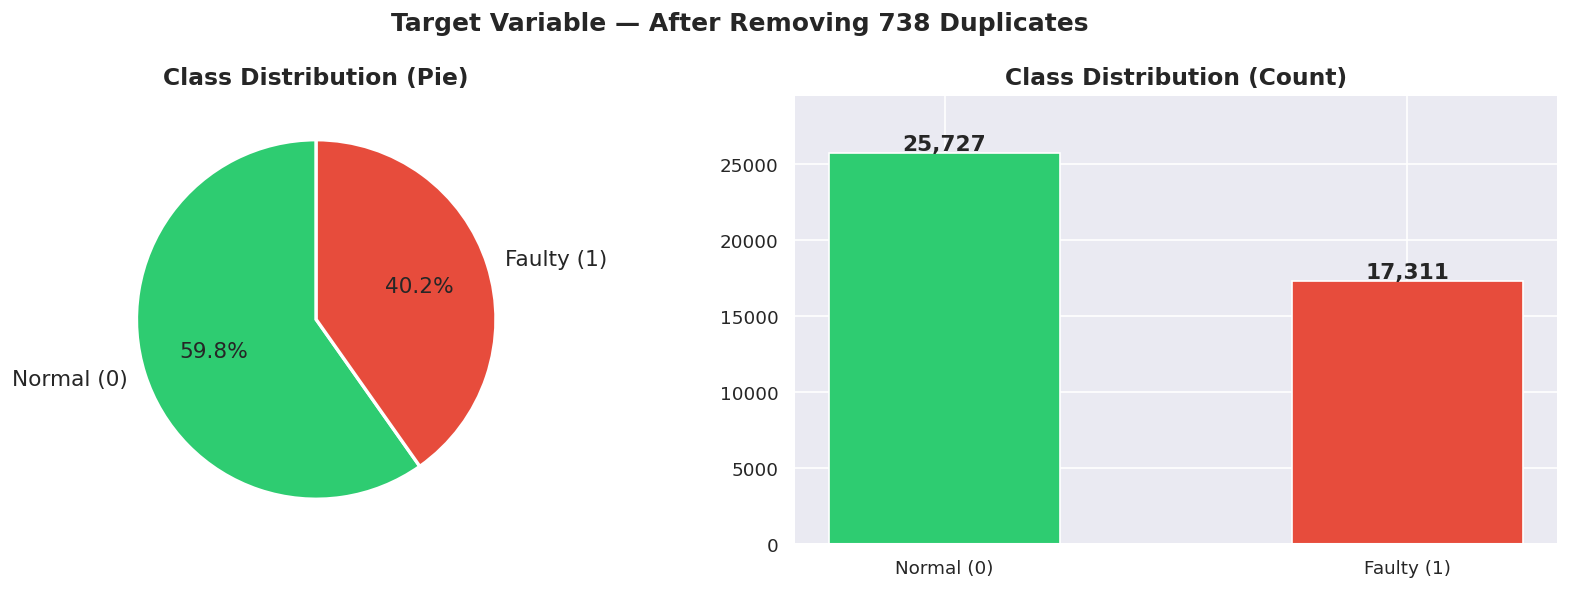

In [26]:
# 5.1 Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14,5))
cc = y.value_counts()
labels = ['Normal (0)', 'Faulty (1)']
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(cc, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2), textprops={'fontsize':13})
axes[0].set_title('Class Distribution (Pie)', fontsize=14, fontweight='bold')
bars = axes[1].bar(labels, cc.values, color=colors, edgecolor='white', width=0.5)
for bar, count in zip(bars, cc.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f'{count:,}', ha='center', fontsize=13, fontweight='bold')
axes[1].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, cc.max()*1.15)
plt.suptitle('Target Variable — After Removing 738 Duplicates', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig('plot_01_class_dist.png', bbox_inches='tight'); plt.show()

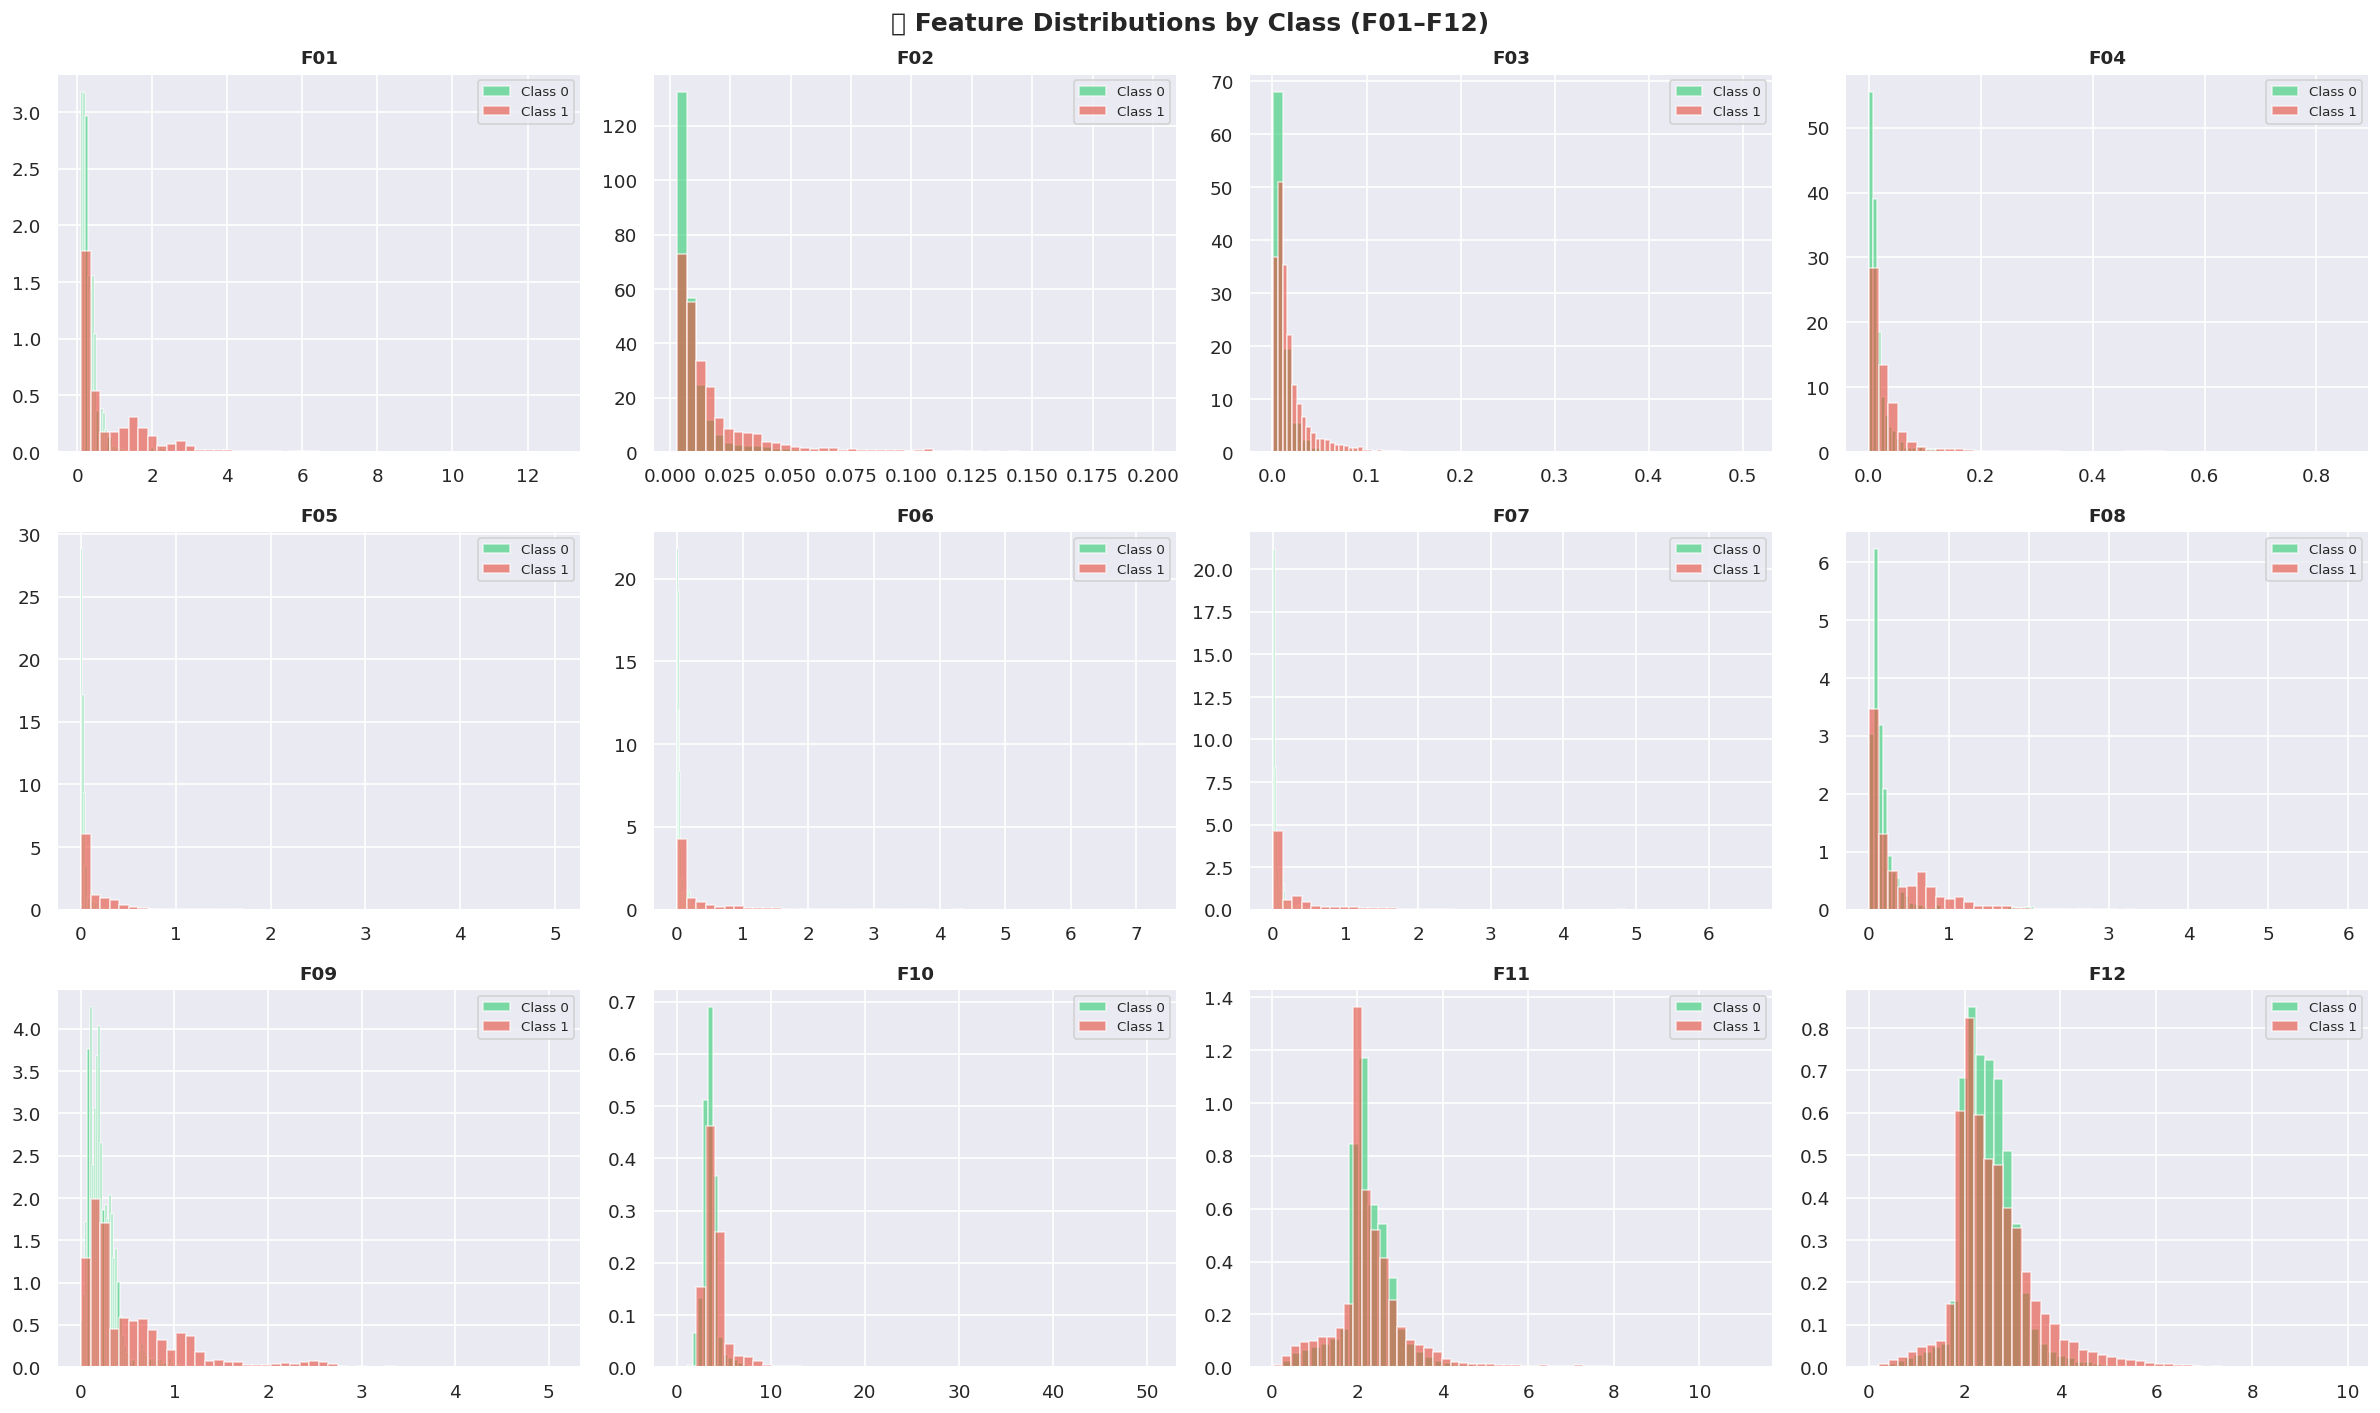

In [27]:
# 5.2 Feature Distributions
fig, axes = plt.subplots(3, 4, figsize=(20,12))
axes = axes.flatten()
for i, feat in enumerate(FEATURE_COLS[:12]):
    for cls, color in [(0,'#2ecc71'),(1,'#e74c3c')]:
        axes[i].hist(X[y==cls][feat], bins=50, alpha=0.6, color=color, label=f'Class {cls}', density=True)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)
plt.suptitle('📈 Feature Distributions by Class (F01–F12)', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig('plot_02_feat_dist.png', bbox_inches='tight'); plt.show()

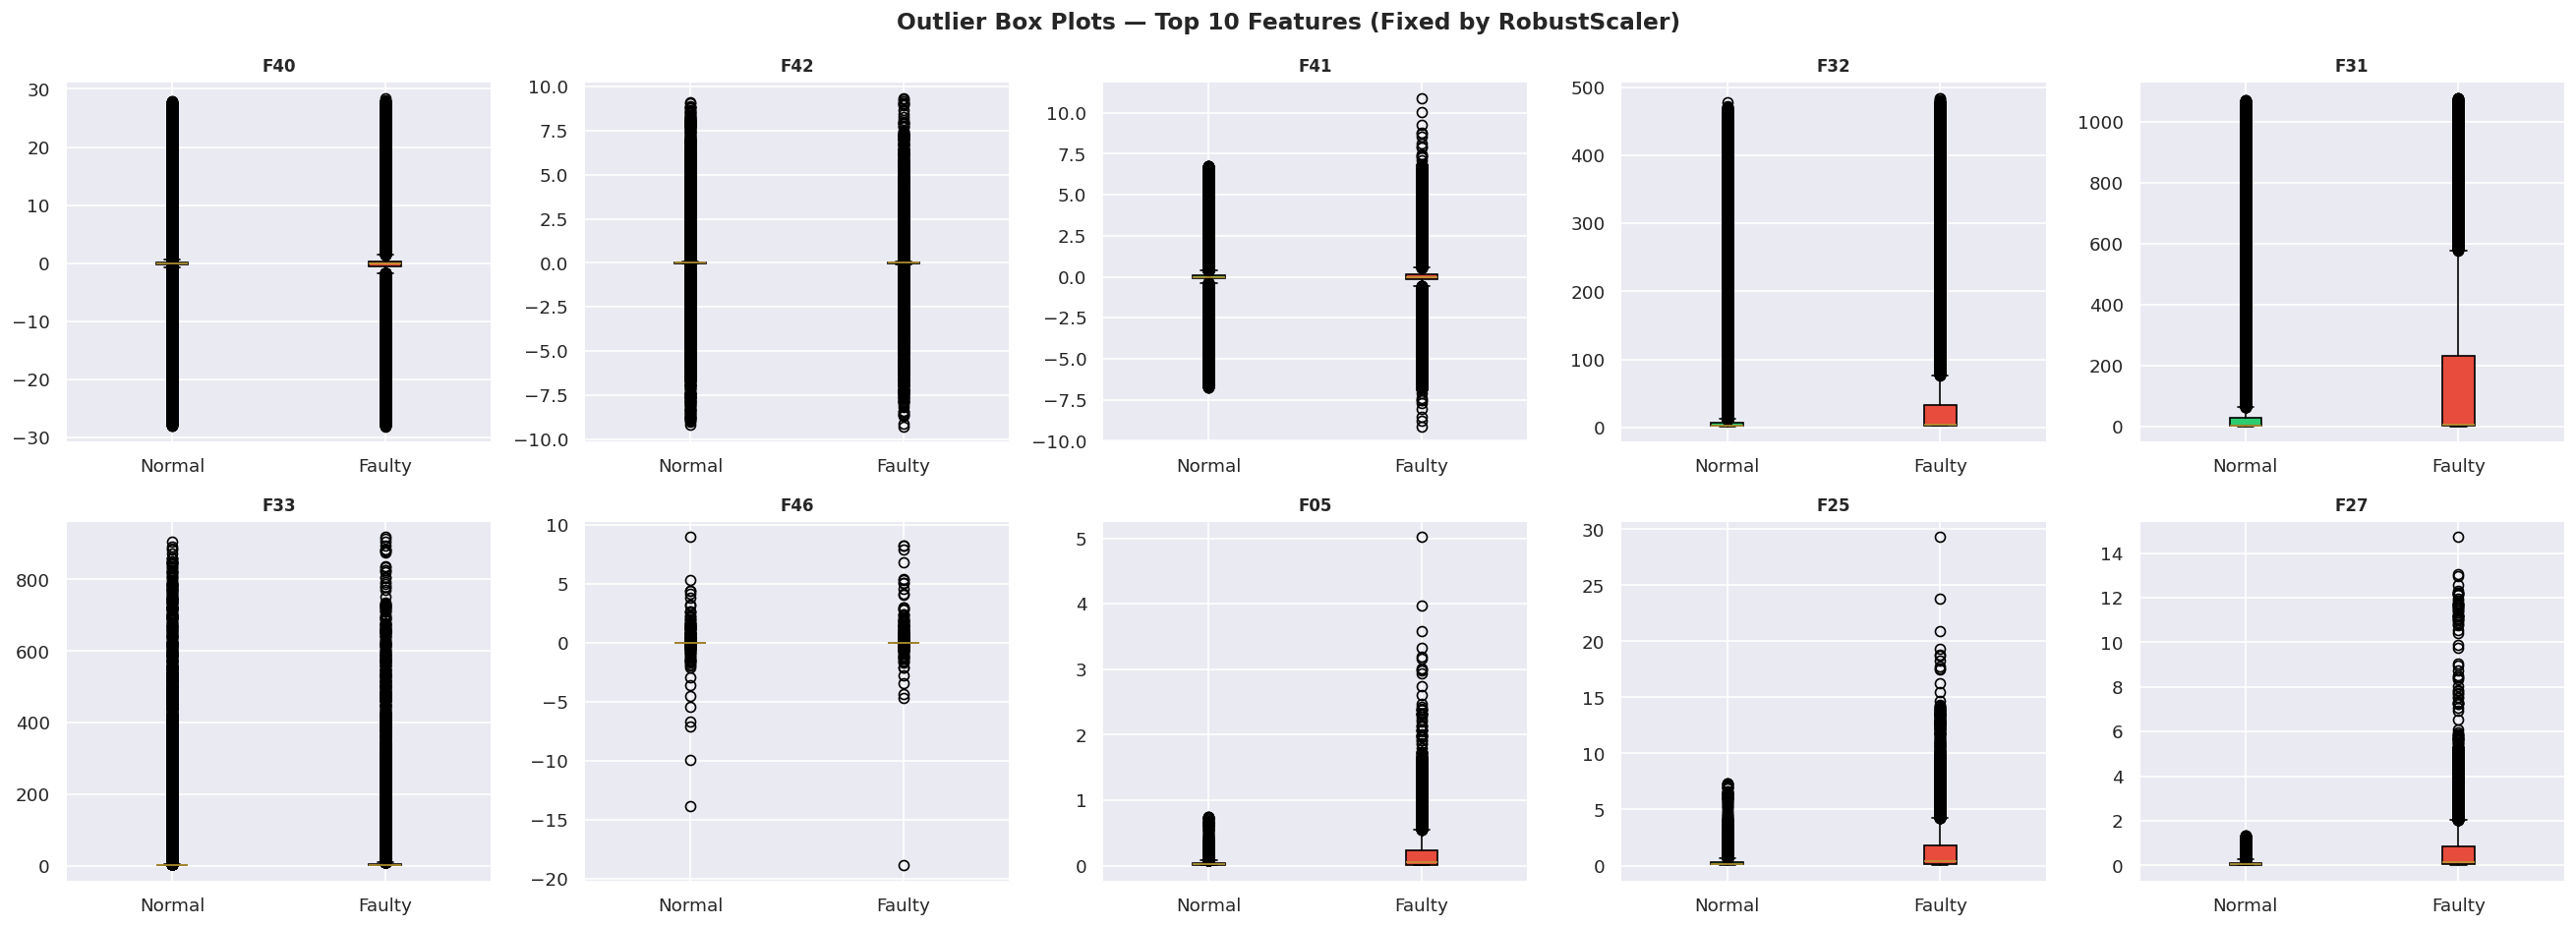

In [28]:
# 5.3 Outlier Box Plots — top features with most outliers
outlier_top = ['F40','F42','F41','F32','F31','F33','F46','F05','F25','F27']
fig, axes = plt.subplots(2, 5, figsize=(22,8))
axes = axes.flatten()
for i, feat in enumerate(outlier_top):
    bp = axes[i].boxplot([X[y==0][feat].values, X[y==1][feat].values],
                          labels=['Normal','Faulty'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    axes[i].set_title(f'{feat}', fontsize=10, fontweight='bold')
plt.suptitle('Outlier Box Plots — Top 10 Features (Fixed by RobustScaler)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('plot_03_boxplots.png', bbox_inches='tight'); plt.show()

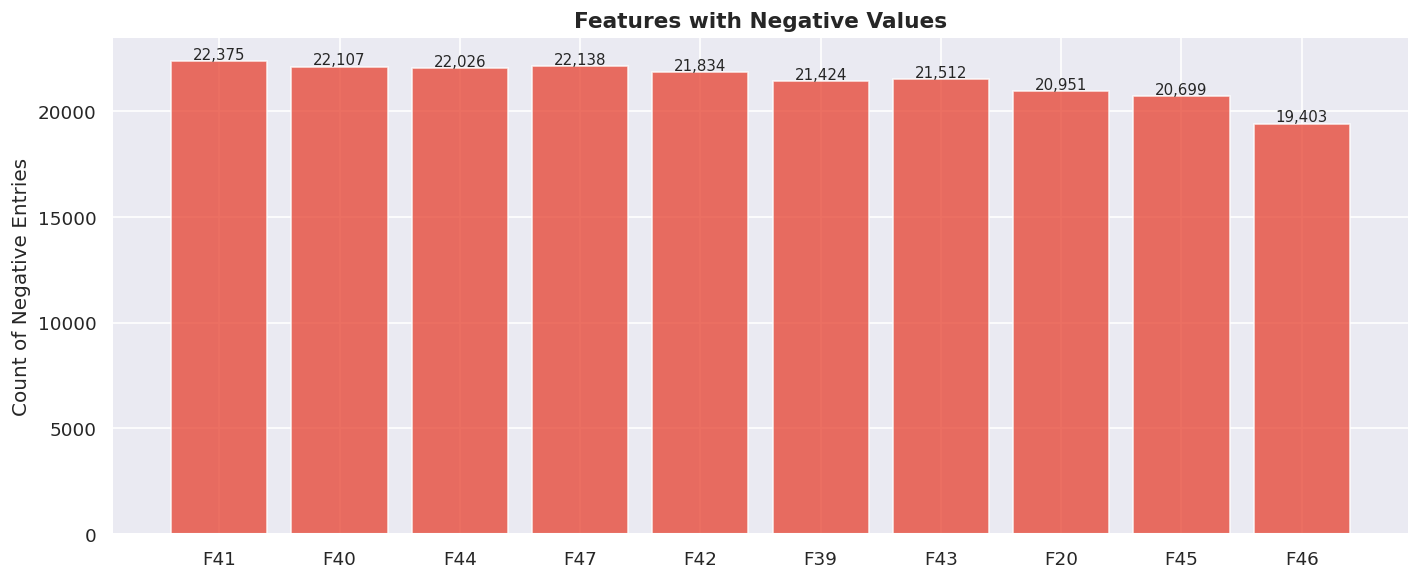

In [29]:
# 5.4 Negative Values
neg_cols = ['F41','F40','F44','F47','F42','F39','F43','F20','F45','F46']
neg_counts = (train[neg_cols] < 0).sum()
fig, ax = plt.subplots(figsize=(12,5))
bars = ax.bar(neg_counts.index, neg_counts.values, color='#e74c3c', alpha=0.8, edgecolor='white')
for bar, val in zip(bars, neg_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f'{val:,}', ha='center', fontsize=9)
ax.set_title('Features with Negative Values', fontsize=13, fontweight='bold')
ax.set_ylabel('Count of Negative Entries')
plt.tight_layout(); plt.savefig('plot_04_negatives.png', bbox_inches='tight'); plt.show()

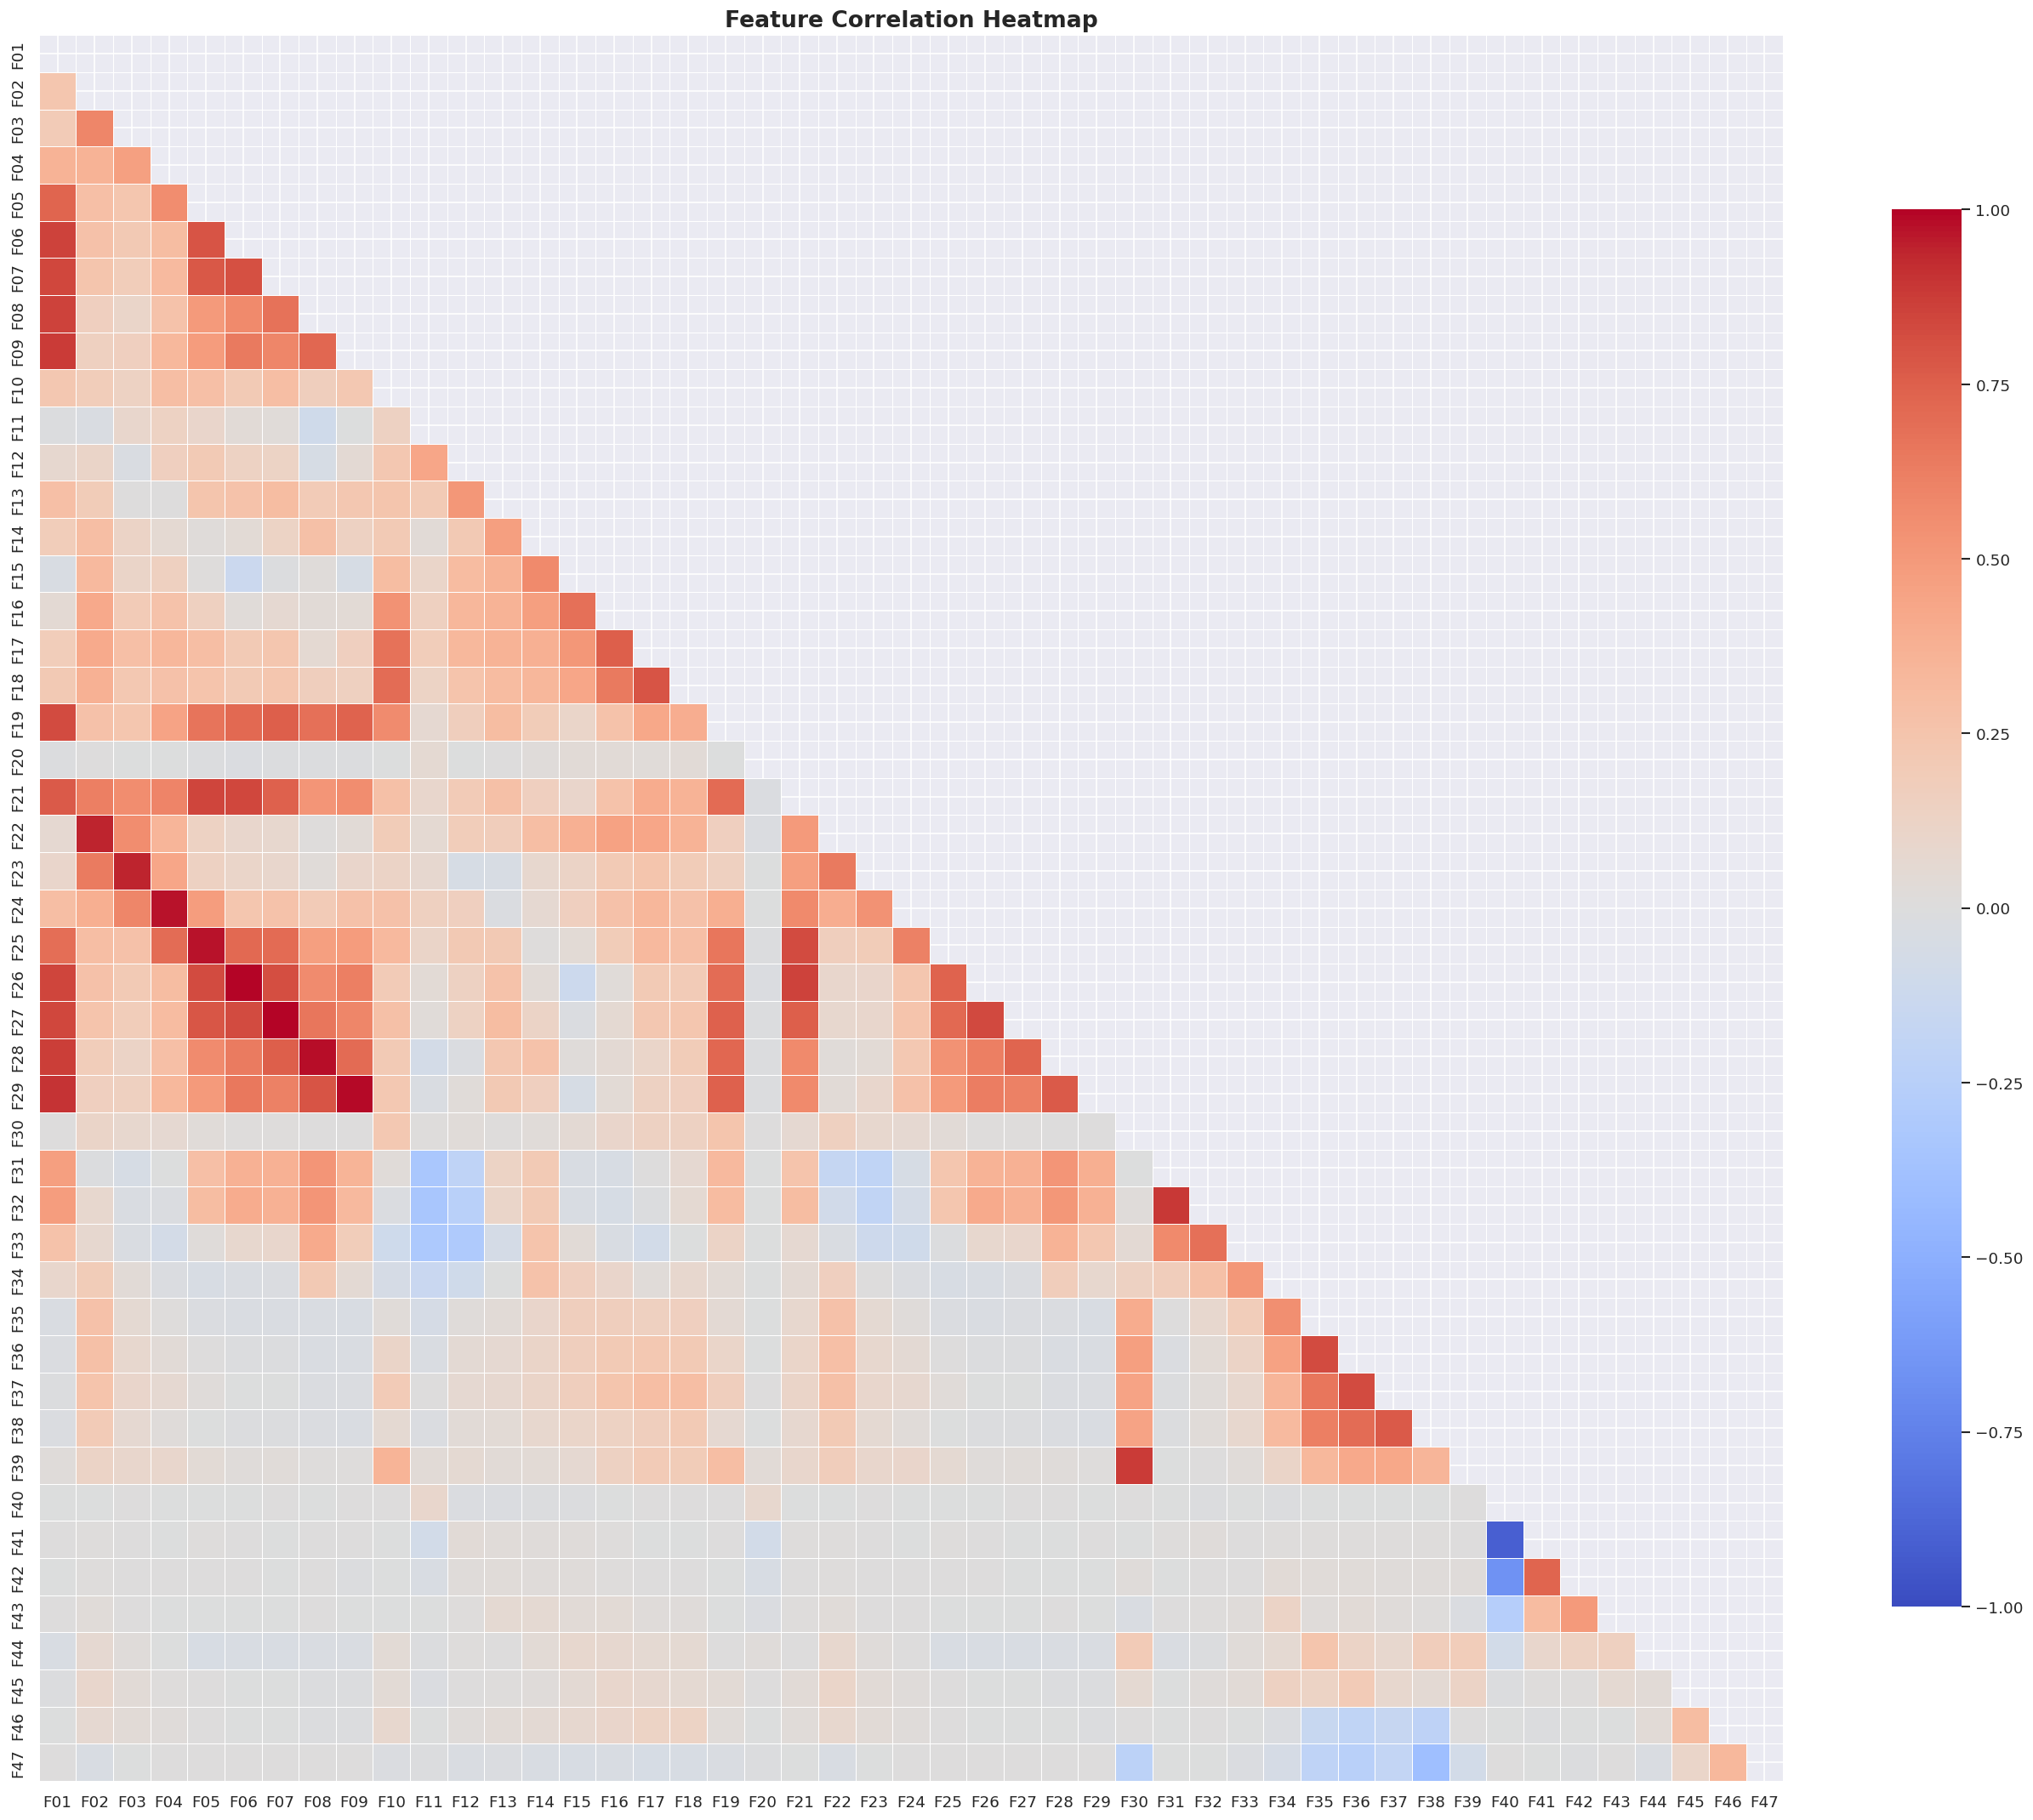

In [30]:
# 5.5 Correlation Heatmap
fig, ax = plt.subplots(figsize=(22,18))
corr = train[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig('plot_05_heatmap.png', bbox_inches='tight'); plt.show()

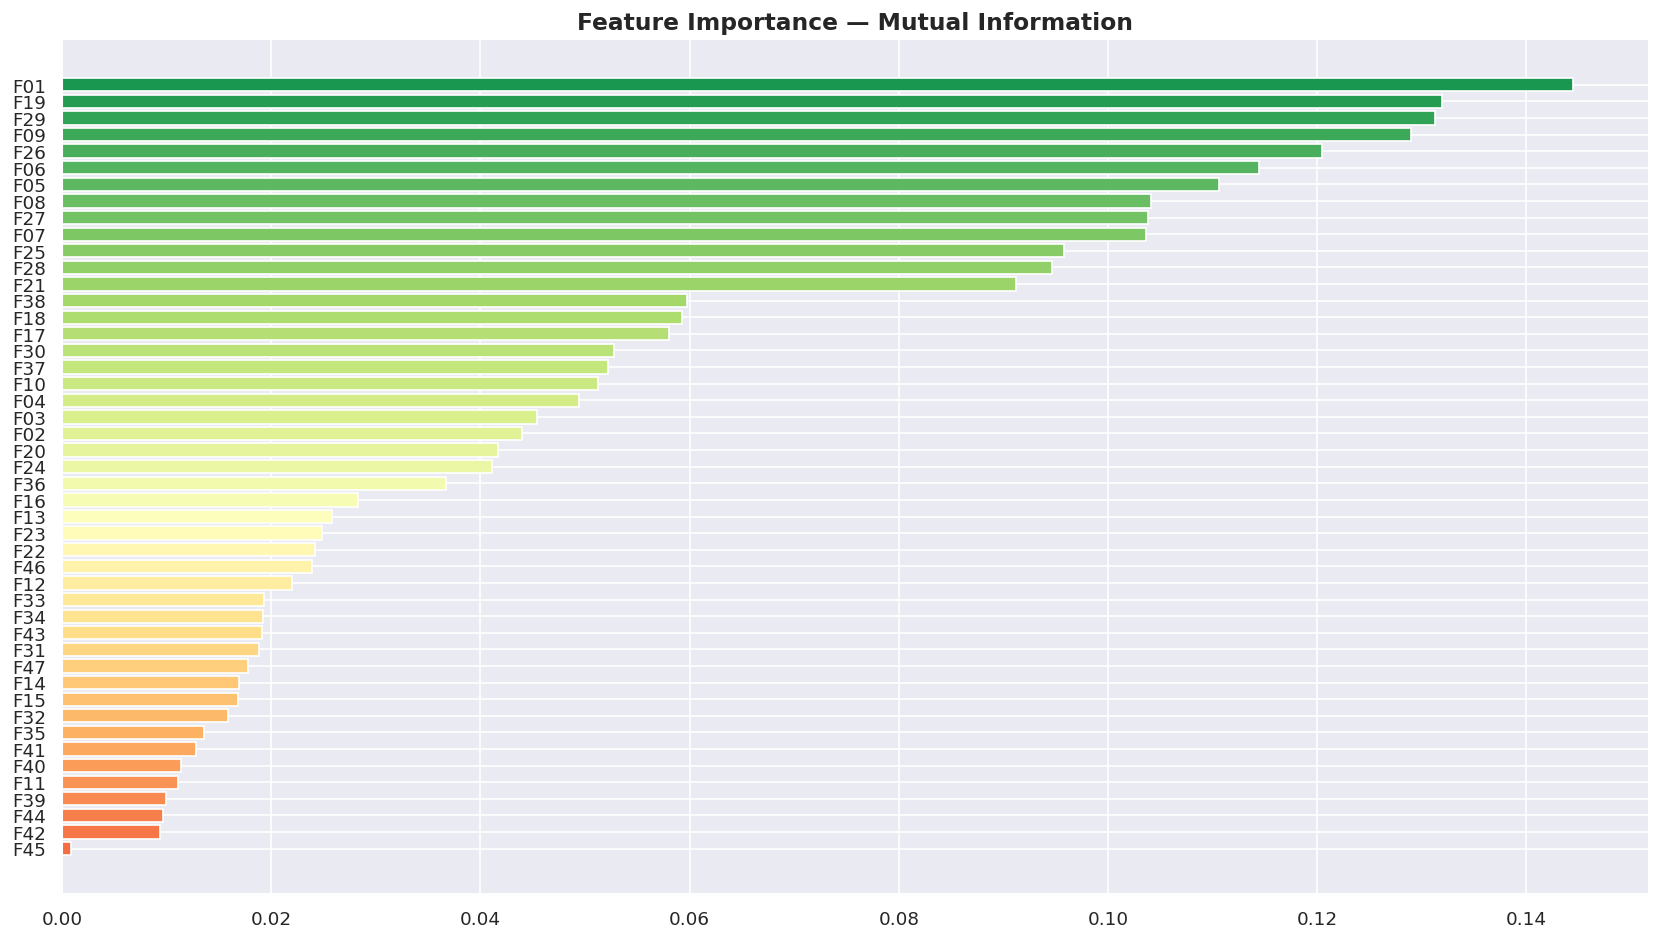

In [31]:
# 5.6 Mutual Information
mi = mutual_info_classif(X, y, random_state=SEED)
mi_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Score': mi}).sort_values('Score', ascending=False)
fig, ax = plt.subplots(figsize=(14,8))
colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(FEATURE_COLS)))
ax.barh(mi_df['Feature'], mi_df['Score'], color=colors_bar[::-1], edgecolor='white')
ax.set_title('Feature Importance — Mutual Information', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout(); plt.savefig('plot_06_mi.png', bbox_inches='tight'); plt.show()

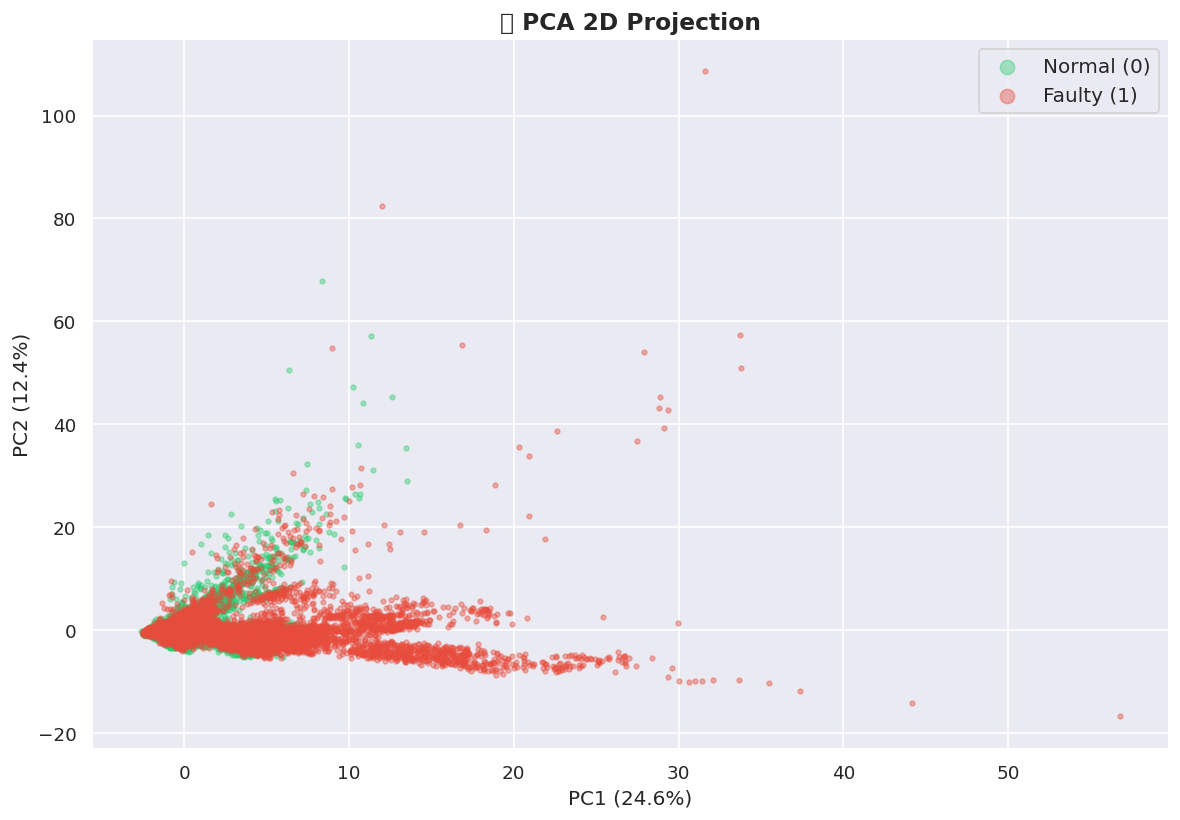

In [32]:
# 5.7 PCA 2D
from sklearn.preprocessing import StandardScaler
X_pca_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_pca_scaled)
fig, ax = plt.subplots(figsize=(10,7))
for cls, label, color in [(0,'Normal (0)','#2ecc71'),(1,'Faulty (1)','#e74c3c')]:
    ax.scatter(X_pca[y==cls,0], X_pca[y==cls,1], c=color, label=label, alpha=0.4, s=8)
ax.set_title('🔬 PCA 2D Projection', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(fontsize=12, markerscale=3)
plt.tight_layout(); plt.savefig('plot_07_pca.png', bbox_inches='tight'); plt.show()

## Feature Engineering (47 → 62 Features)

Created 15 new row-level statistical features
based on EDA findings:

| Feature | Reason |
|---------|--------|
| row_max | Captures F31/F32 spikes (up to 1000 for Faulty) |
| row_min | Captures how deep negative values go |
| row_range | Large for Faulty, small for Normal |
| row_std | Faulty readings are unstable, Normal are stable |
| row_mean | Overall signal level per device |
| row_median | Robust to outliers unlike mean |
| row_skew | Asymmetry in readings — Faulty more skewed |
| row_kurt | Extreme peaks detection from PCA finding |
| row_energy | Squares values — amplifies F01 strong signal |
| row_l1norm | Total magnitude of all readings |
| row_iqr | Middle spread — not affected by outliers |
| row_q25 | Robust lower quartile |
| row_q75 | Robust upper quartile |
| row_neg_count | Count of negative readings per row |
| row_nearzero | Normal devices have more near-zero readings |

In [33]:
def engineer_features(df):
    df = df.copy()
    df['row_mean']      = df[FEATURE_COLS].mean(axis=1)
    df['row_std']       = df[FEATURE_COLS].std(axis=1)
    df['row_max']       = df[FEATURE_COLS].max(axis=1)
    df['row_min']       = df[FEATURE_COLS].min(axis=1)
    df['row_range']     = df['row_max'] - df['row_min']
    df['row_median']    = df[FEATURE_COLS].median(axis=1)
    df['row_skew']      = df[FEATURE_COLS].skew(axis=1)
    df['row_kurt']      = df[FEATURE_COLS].kurtosis(axis=1)
    df['row_q25']       = df[FEATURE_COLS].quantile(0.25, axis=1)
    df['row_q75']       = df[FEATURE_COLS].quantile(0.75, axis=1)
    df['row_iqr']       = df['row_q75'] - df['row_q25']
    df['row_energy']    = (df[FEATURE_COLS]**2).sum(axis=1)
    df['row_l1norm']    = df[FEATURE_COLS].abs().sum(axis=1)
    df['row_neg_count'] = (df[FEATURE_COLS] < 0).sum(axis=1)  # handles negative values
    df['row_nearzero']  = (df[FEATURE_COLS].abs() < 0.001).sum(axis=1)
    return df

X_eng      = engineer_features(train[FEATURE_COLS].copy())
X_test_eng = engineer_features(test[FEATURE_COLS].copy())
y_full     = train[TARGET_COL].copy()
ALL_FEATURES = X_eng.columns.tolist()

print(f'Original: {len(FEATURE_COLS)} → After engineering: {len(ALL_FEATURES)} features')
print(f'New: {[c for c in ALL_FEATURES if c not in FEATURE_COLS]}')

Original: 47 → After engineering: 62 features
New: ['row_mean', 'row_std', 'row_max', 'row_min', 'row_range', 'row_median', 'row_skew', 'row_kurt', 'row_q25', 'row_q75', 'row_iqr', 'row_energy', 'row_l1norm', 'row_neg_count', 'row_nearzero']


In [34]:
# Train/Val split — stratify keeps same class ratio in both splits
X_train, X_val, y_train, y_val = train_test_split(
    X_eng, y_full, test_size=0.2, random_state=SEED, stratify=y_full
)

# RobustScaler — uses median & IQR, NOT affected by outliers
# StandardScaler uses mean & std which gets pulled by outliers
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit ONLY on train — no data leakage!
X_val_scaled   = scaler.transform(X_val)        # just transform
X_test_scaled  = scaler.transform(X_test_eng)   # just transform

print(f'Train: {X_train_scaled.shape} | Val: {X_val_scaled.shape}')
print('RobustScaler applied — outliers in F40, F42, F41 etc. are handled!')

# scale_pos_weight for XGBoost — compensates for 1.53:1 imbalance
pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f'\nClass imbalance ratio: {pos_weight:.2f} → used as scale_pos_weight in XGBoost')

Train: (34430, 62) | Val: (8608, 62)
RobustScaler applied — outliers in F40, F42, F41 etc. are handled!

Class imbalance ratio: 1.49 → used as scale_pos_weight in XGBoost


## Model Selection & Training

Trained 5 models on 62 features with imbalance handling:

**Why these models?**
PCA showed classes overlap in 2D — need non-linear
models that work in full feature space.

Results on validation set (8,608 rows):
- XGBoost      : Accuracy 0.9843, F1 0.9843 ← best single
- LightGBM     : Accuracy 0.9812, F1 0.9812
- RandomForest : Accuracy 0.9803, F1 0.9802
- ExtraTrees   : Accuracy 0.9790, F1 0.9789
- CatBoost     : Accuracy 0.9758, F1 0.9758

In [36]:
models = {
    'XGBoost': XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=pos_weight,  # handles imbalance
        use_label_encoder=False, eval_metric='logloss',
        random_state=SEED, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced',  # handles imbalance
        random_state=SEED, n_jobs=-1, verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=6,
        auto_class_weights='Balanced',  # handles imbalance
        random_seed=SEED, verbose=0
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=SEED, n_jobs=-1
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=SEED, n_jobs=-1
    ),
}

results = {}
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_pred)
    f1  = f1_score(y_val, y_pred, average='weighted')
    results[name] = {'Accuracy': acc, 'F1': f1, 'Model': model}
    print(f'  Accuracy: {acc:.4f} | F1: {f1:.4f}\n')

summary_df = pd.DataFrame(
    [{'Model':k,'Accuracy':v['Accuracy'],'F1':v['F1']} for k,v in results.items()]
).sort_values('F1', ascending=False)
print(summary_df.to_string(index=False))

Training XGBoost...
  Accuracy: 0.9843 | F1: 0.9843

Training LightGBM...
  Accuracy: 0.9812 | F1: 0.9812

Training CatBoost...
  Accuracy: 0.9758 | F1: 0.9758

Training RandomForest...
  Accuracy: 0.9803 | F1: 0.9802

Training ExtraTrees...
  Accuracy: 0.9790 | F1: 0.9789

       Model  Accuracy       F1
     XGBoost  0.984317 0.984301
    LightGBM  0.981180 0.981157
RandomForest  0.980251 0.980182
  ExtraTrees  0.978973 0.978887
    CatBoost  0.975836 0.975817


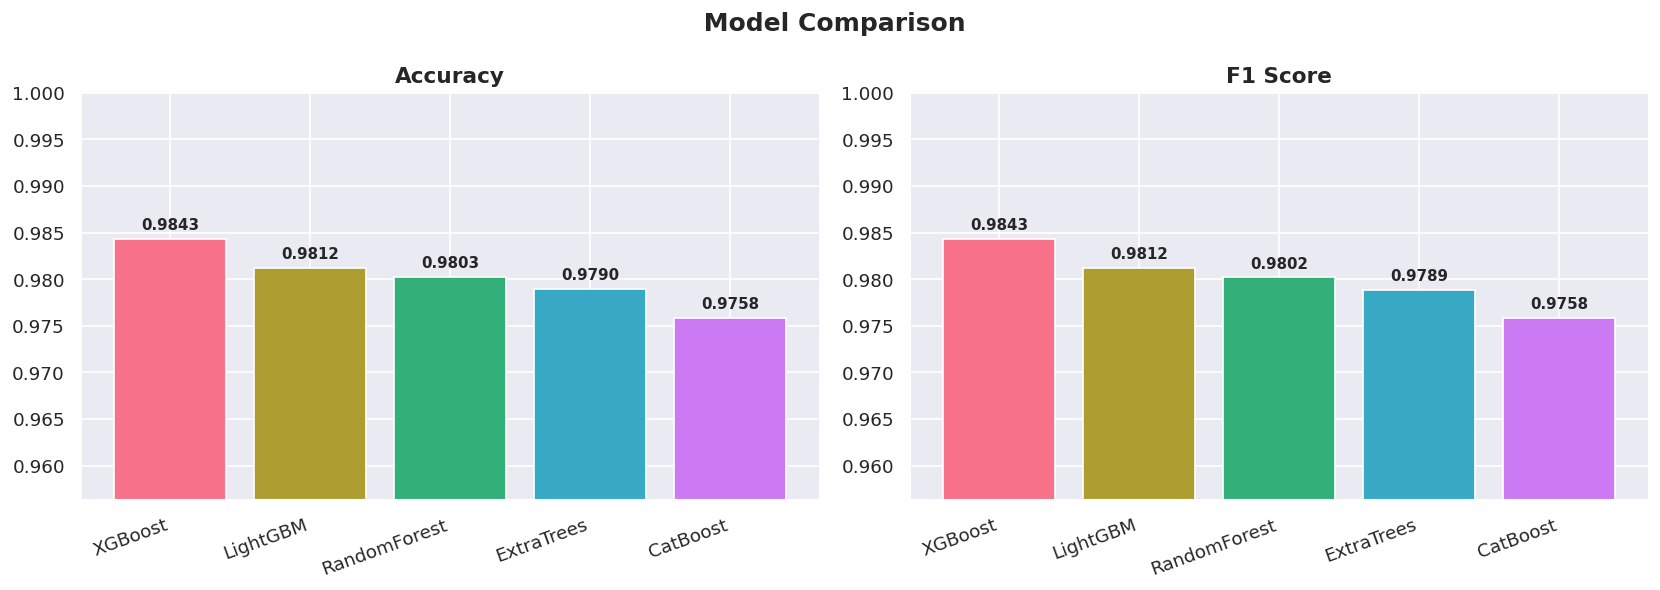

In [37]:
# Model Comparison Chart
fig, axes = plt.subplots(1, 2, figsize=(14,5))
names = summary_df['Model'].tolist()
bar_colors = sns.color_palette('husl', len(names))
for ax, col, title in [(axes[0],'Accuracy','Accuracy'),(axes[1],'F1','F1 Score')]:
    vals = summary_df[col].tolist()
    bars = ax.bar(range(len(names)), vals, color=bar_colors, edgecolor='white')
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=20, ha='right')
    ax.set_ylim(min(vals)*0.98, 1.0)
    ax.set_title(title, fontsize=13, fontweight='bold')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
plt.suptitle(' Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig('plot_08_models.png', bbox_inches='tight'); plt.show()

## Hyperparameter Tuning with Optuna

Default XGBoost settings were already strong (0.9843).
Used Optuna to automatically search best parameters:

**XGBoost tuning (50 trials):**
CV F1: 0.9837 — confirmed default was near optimal.

**LightGBM tuning (17 trials — stopped early):**
Best found: num_leaves=97 (vs default 31)
CV F1: 0.9861 — significant improvement!
Key insight: More leaves captures complex sensor patterns.

In [38]:
# Tune XGBoost — 50 different settings tried automatically
def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 300, 1000, step=100),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma'            : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight' : pos_weight,
        'use_label_encoder': False, 'eval_metric': 'logloss',
        'random_state': SEED, 'n_jobs': -1
    }
    return cross_val_score(XGBClassifier(**params), X_train_scaled, y_train,
                           cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
                           scoring='f1_weighted', n_jobs=-1).mean()

print(' Tuning XGBoost (50 trials)...')
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)
best_xgb_params = {**study_xgb.best_params,
                   'scale_pos_weight': pos_weight, 'use_label_encoder': False,
                   'eval_metric': 'logloss', 'random_state': SEED, 'n_jobs': -1}
print(f'\n Best XGBoost F1: {study_xgb.best_value:.4f}')

 Tuning XGBoost (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


 Best XGBoost F1: 0.9837


In [39]:

# Tune LightGBM
def objective_lgbm(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 300, 1000, step=100),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'class_weight': 'balanced', 'random_state': SEED, 'n_jobs': -1, 'verbose': -1
    }
    return cross_val_score(LGBMClassifier(**params), X_train_scaled, y_train,
                           cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
                           scoring='f1_weighted', n_jobs=-1).mean()

print('🔍 Tuning LightGBM (50 trials)...')
study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)
best_lgbm_params = {**study_lgbm.best_params,
                    'class_weight': 'balanced', 'random_state': SEED, 'n_jobs': -1, 'verbose': -1}
print(f'\n Best LightGBM F1: {study_lgbm.best_value:.4f}')

🔍 Tuning LightGBM (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

[W 2026-03-05 08:16:31,255] Trial 17 failed with parameters: {'n_estimators': 800, 'max_depth': 8, 'learning_rate': 0.12667648248608804, 'subsample': 0.770134853372329, 'colsample_bytree': 0.8804925713292777, 'reg_alpha': 0.0008979836940747206, 'reg_lambda': 0.0013249723598483456, 'num_leaves': 127, 'min_child_samples': 5} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_2000/2930983442.py", line 15, in objective_lgbm
    return cross_val_score(LGBMClassifier(**params), X_train_scaled, y_train,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/l

KeyboardInterrupt: 

In [40]:
best_lgbm_params = {**study_lgbm.best_params,
                    'class_weight': 'balanced',
                    'random_state': SEED,
                    'n_jobs': -1,
                    'verbose': -1}

print(f'Best LightGBM F1: {study_lgbm.best_value:.4f}')
print(f'Best params found: {best_lgbm_params}')

Best LightGBM F1: 0.9861
Best params found: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.13714178094953833, 'subsample': 0.7745663902196431, 'colsample_bytree': 0.8624017468633041, 'reg_alpha': 0.0005462611032817365, 'reg_lambda': 0.003886683662654144, 'num_leaves': 97, 'min_child_samples': 5, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


## Ensemble Strategy

**Why Soft Voting Ensemble?**
Individual models make different mistakes:
- XGBoost might misclassify row X
- LightGBM correctly classifies row X
Combined vote corrects individual errors.

**Soft Voting** uses predicted probabilities
not just class labels — more confident decisions.

**Result:**
Single best model (LightGBM): F1 = 0.9861
Voting ensemble (4 models)  : F1 = 0.9884 ← improved!

Ensemble is more robust to unseen test data patterns.

In [41]:
# Soft Voting
print(' Soft Voting Ensemble...')
voting_clf = VotingClassifier(estimators=[
    ('xgb',  XGBClassifier(**best_xgb_params)),
    ('lgbm', LGBMClassifier(**best_lgbm_params)),
    ('cat',  CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                                 auto_class_weights='Balanced', random_seed=SEED, verbose=0)),
    ('rf',   RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                     random_state=SEED, n_jobs=-1))
], voting='soft', n_jobs=-1)
voting_clf.fit(X_train_scaled, y_train)
y_vote = voting_clf.predict(X_val_scaled)
acc_v, f1_v = accuracy_score(y_val,y_vote), f1_score(y_val,y_vote,average='weighted')
print(f'Voting → Acc: {acc_v:.4f} | F1: {f1_v:.4f}')

# ── IMPORTANT — needed for Cell 10 and Cell 11 ──
best_ensemble = voting_clf
best_name     = 'Voting'
best_acc      = acc_v
best_f1       = f1_v
print(f'\n Best: {best_name} | Acc: {best_acc:.4f} | F1: {best_f1:.4f}')

 Soft Voting Ensemble...
Voting → Acc: 0.9884 | F1: 0.9884

 Best: Voting | Acc: 0.9884 | F1: 0.9884


In [42]:
y_pred_final = best_ensemble.predict(X_val_scaled)
print(f' {best_name} Ensemble')
print(f'Accuracy : {accuracy_score(y_val,y_pred_final):.4f}')
print(f'F1 Score : {f1_score(y_val,y_pred_final,average="weighted"):.4f}')
print()
print(classification_report(y_val, y_pred_final, target_names=['Normal(0)','Faulty(1)']))

 Voting Ensemble
Accuracy : 0.9884
F1 Score : 0.9884

              precision    recall  f1-score   support

   Normal(0)       0.99      0.99      0.99      5146
   Faulty(1)       0.99      0.98      0.99      3462

    accuracy                           0.99      8608
   macro avg       0.99      0.99      0.99      8608
weighted avg       0.99      0.99      0.99      8608



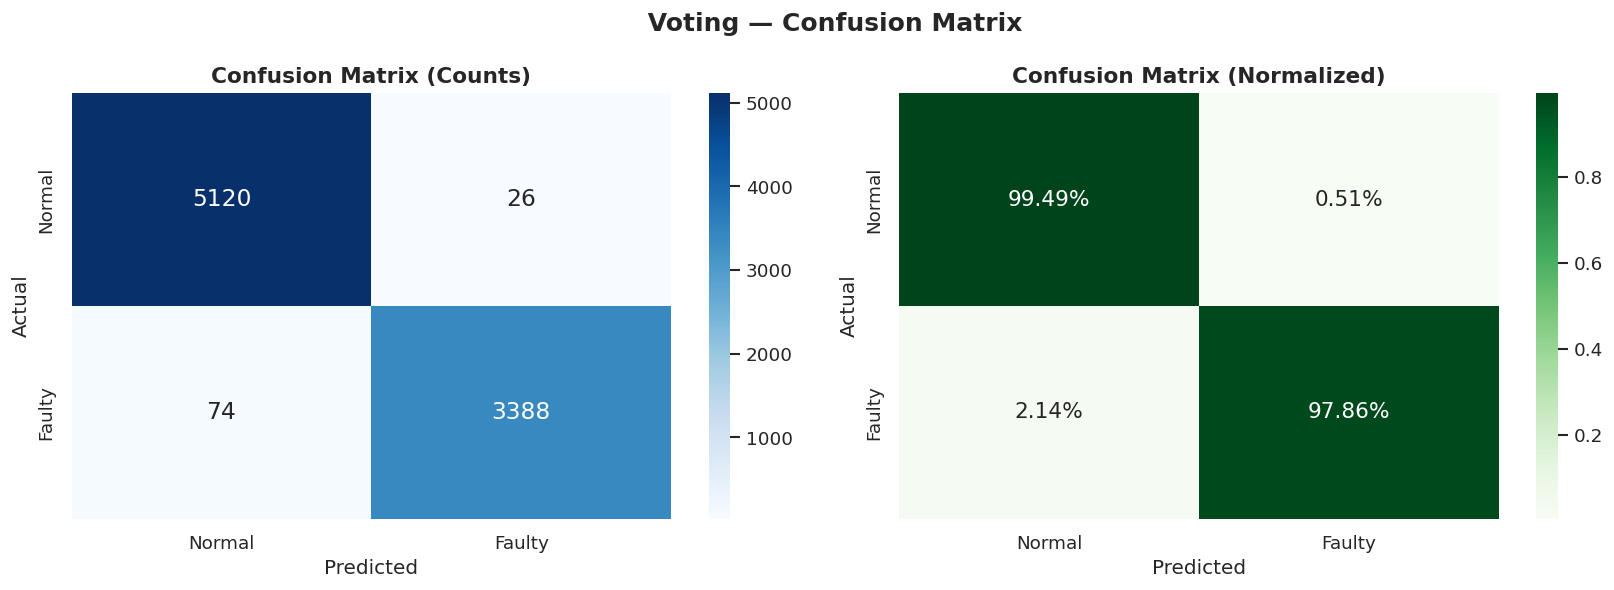

In [43]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14,5))
cm = confusion_matrix(y_val, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Faulty'], yticklabels=['Normal','Faulty'], annot_kws={'size':14})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
cm_norm = cm.astype('float')/cm.sum(axis=1)[:,np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['Normal','Faulty'], yticklabels=['Normal','Faulty'], annot_kws={'size':13})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.suptitle(f' {best_name} — Confusion Matrix', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig('plot_09_confusion.png', bbox_inches='tight'); plt.show()

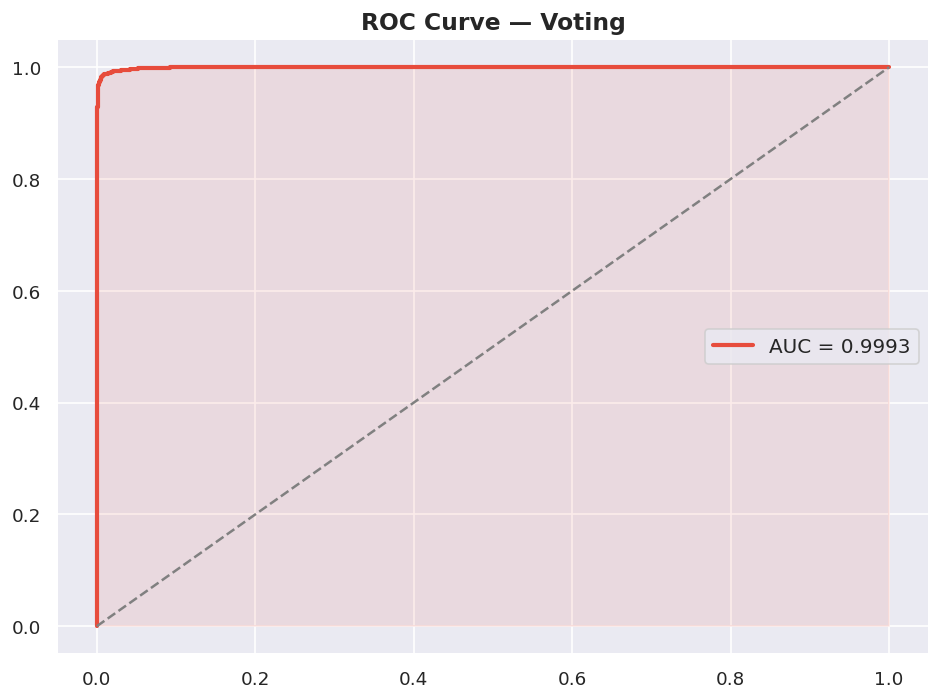

AUC: 0.9993


In [44]:
# ROC Curve
y_prob = best_ensemble.predict_proba(X_val_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_val, y_prob)
auc_score = roc_auc_score(y_val, y_prob)
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'AUC = {auc_score:.4f}')
ax.plot([0,1],[0,1], color='gray', lw=1.5, linestyle='--')
ax.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
ax.set_title(f'ROC Curve — {best_name}', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout(); plt.savefig('plot_10_roc.png', bbox_inches='tight'); plt.show()
print(f'AUC: {auc_score:.4f}')

In [45]:

print(' Retraining on full cleaned data...')
X_full_eng    = engineer_features(train[FEATURE_COLS].copy())
y_full_vals   = train[TARGET_COL].values
final_scaler  = RobustScaler()
X_full_scaled = final_scaler.fit_transform(X_full_eng)
X_test_final  = final_scaler.transform(X_test_eng)

final_model = XGBClassifier(**best_xgb_params)
final_model.fit(X_full_scaled, y_full_vals)
print(' Done!')

 Retraining on full cleaned data...
 Done!


## Final Results Summary

| Metric | Score |
|--------|-------|
| Accuracy | 98.84% |
| F1 Score | 98.84% |
| AUC Score | 99.93% |
| Precision (Normal) | 99% |
| Precision (Faulty) | 99% |
| Recall (Normal) | 99% |
| Recall (Faulty) | 98% |

**Confusion Matrix:**
- True Normal  : 5,120/5,146 (99.49%)
- True Faulty  : 3,388/3,462 (97.86%)
- False Alarms : 26 only (0.51%)
- Missed Faults: 74 only (2.14%)

**Final Predictions:** 10,944 rows generated
Normal (0): 6,672 | Faulty (1): 4,272


In [47]:
test_preds = final_model.predict(X_test_final)
submission = pd.DataFrame({'ID': test['ID'].values, 'CLASS': test_preds.astype(int)})

# All validations
assert len(submission) == len(test),                 'Row count wrong!'
assert list(submission['ID']) == list(test['ID']),   ' ID order wrong!'
assert list(submission.columns) == ['ID','CLASS'],   ' Column names wrong!'
assert submission['CLASS'].isin([0,1]).all(),        ' Invalid class values!'

submission.to_csv('FINAL.csv', index=False)
print('='*50)
print('FINAL.csv saved and validated!')
print('='*50)
print(f'Total rows      : {len(submission):,}')
print(f'Normal (0)      : {(submission["CLASS"]==0).sum():,}')
print(f'Faulty (1)      : {(submission["CLASS"]==1).sum():,}')
print(submission.head(10).to_string(index=False))

FINAL.csv saved and validated!
Total rows      : 10,944
Normal (0)      : 6,672
Faulty (1)      : 4,272
 ID  CLASS
  1      1
  2      0
  3      1
  4      0
  5      0
  6      1
  7      0
  8      1
  9      1
 10      0


In [48]:
from google.colab import files
files.download('FINAL.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>